In [1]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub


/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


# IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import Ridge, Lasso

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA

# LOAD DATASET

In [3]:
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 2640
Columns: 12


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# DATASET INFORMATION

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [5]:
print(df.columns.tolist())

['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [6]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# DATA PREPROCESSING

In [7]:
print("Missing Values:")
print(df.columns.tolist())

Missing Values:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [8]:
print("Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("New Shape:", df.shape)

Duplicate Rows: 0
New Shape: (2640, 12)


# DATA TYPES

In [9]:
print(df.dtypes)

Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object


# EXPLORATORY DATA ANALYSIS (EDA)

## Deliveries Trend

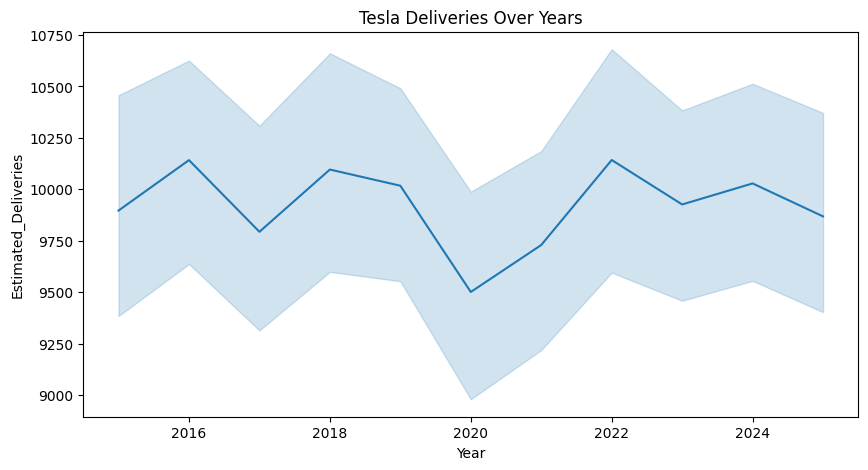

In [10]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df,x='Year',y='Estimated_Deliveries')
plt.title("Tesla Deliveries Over Years")
plt.show()

## Production Trend

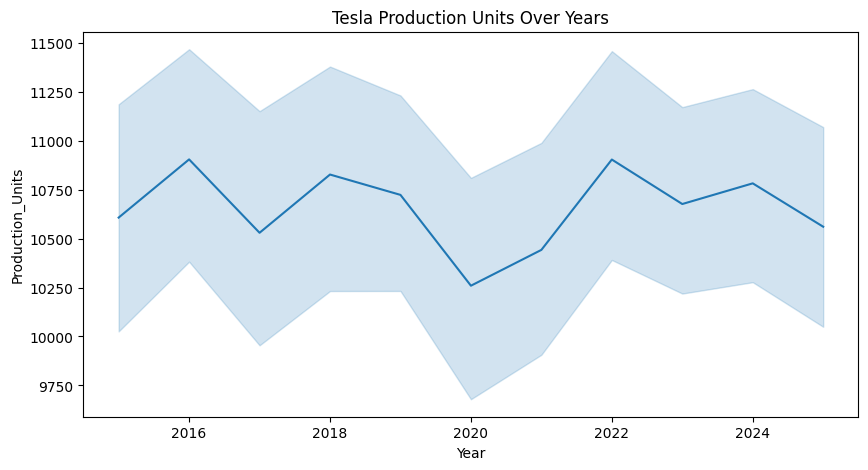

In [11]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df,x='Year',y='Production_Units')
plt.title("Tesla Production Units Over Years")
plt.show()

## Average Price Trend

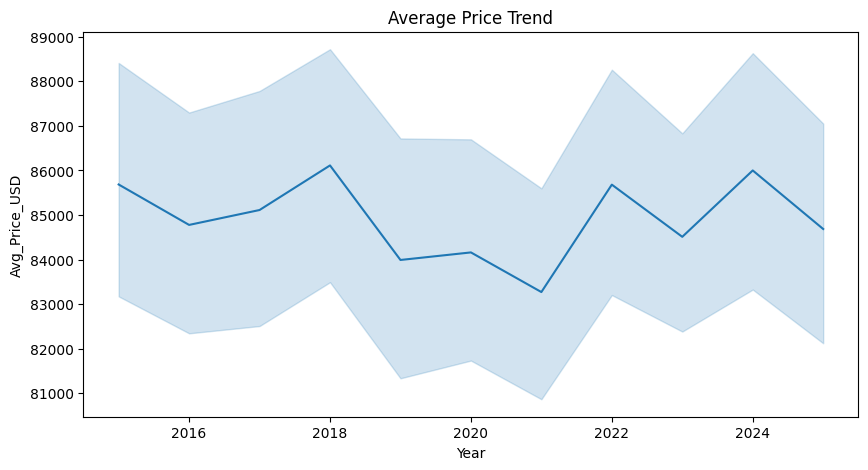

In [12]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df,x='Year',y='Avg_Price_USD')
plt.title("Average Price Trend")
plt.show()

## Outlier Detection

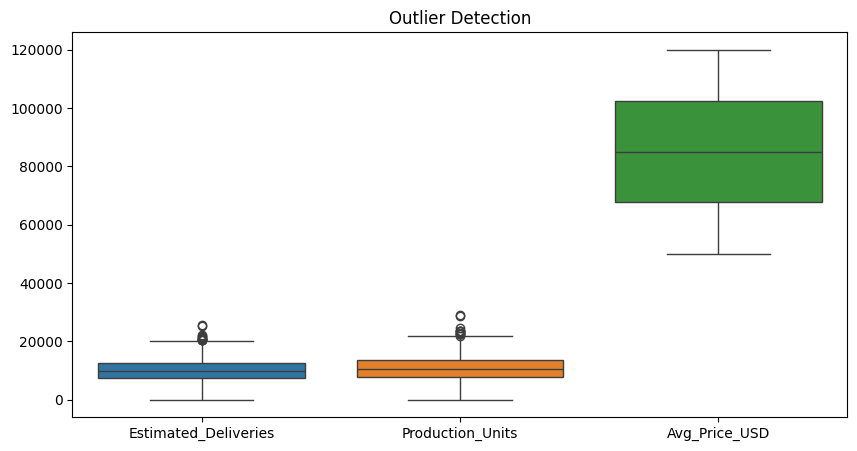

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df[['Estimated_Deliveries',
             'Production_Units',
             'Avg_Price_USD']]
)

plt.title("Outlier Detection")
plt.show()

## Correlation Heatmap

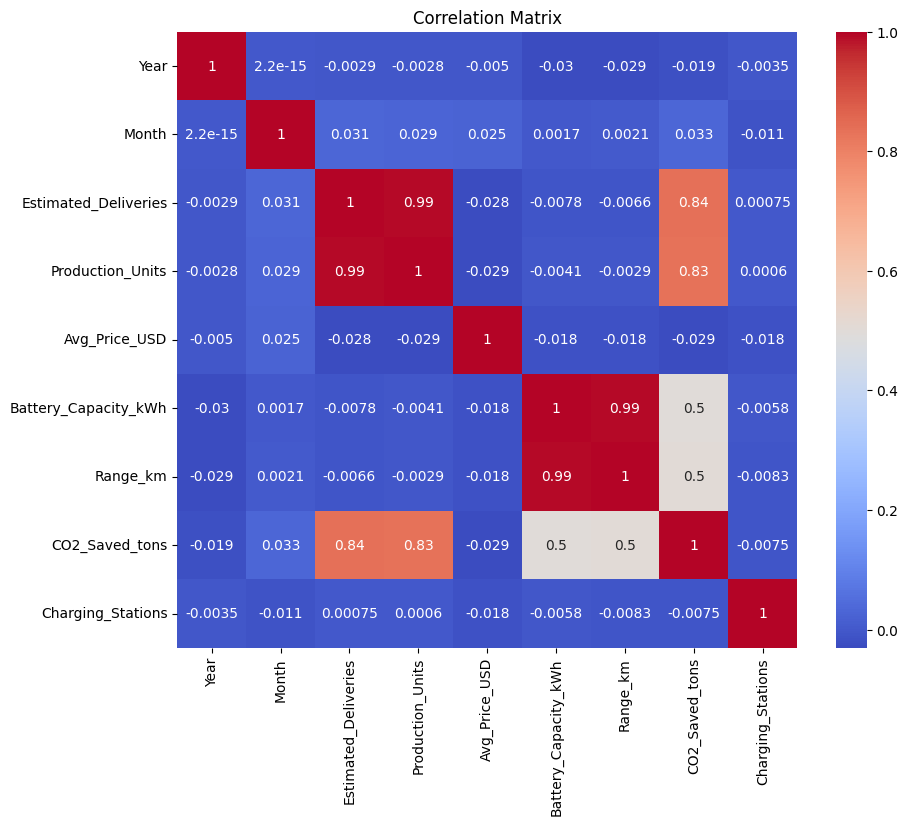

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

# Feature Engineering

## Delivery Efficiency

In [15]:
df['Delivery_Efficiency'] = (
    df['Estimated_Deliveries'] /
    df['Production_Units']
)

## Price Per Range

In [16]:
df['Price_Per_Range'] = (
    df['Avg_Price_USD'] /
    df['Range_km']
)

## Price Per Battery Capacity

In [17]:
df['Price_Per_kWh'] = (
    df['Avg_Price_USD'] /
    df['Battery_Capacity_kWh']
)

In [18]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Delivery_Efficiency,Price_Per_Range,Price_Per_kWh
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,0.984600,131.923679,773.952250
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,0.911864,142.022032,829.408667
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,0.915334,245.598583,1437.650244
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,0.896594,125.414199,744.124250
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,0.914087,173.747020,957.056500


# ENCODING CATEGORICAL VARIABLES

In [19]:
le = LabelEncoder()
df['Region'] = le.fit_transform(df['Region'])
df['Model'] = le.fit_transform(df['Model'])
df['Source_Type'] = le.fit_transform(df['Source_Type'])

In [20]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Delivery_Efficiency,Price_Per_Range,Price_Per_kWh
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,0.984600,131.923679,773.952250
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,0.911864,142.022032,829.408667
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,0.915334,245.598583,1437.650244
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,0.896594,125.414199,744.124250
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,0.914087,173.747020,957.056500


# REGRESSION MODELING

## Define Features and Target

In [21]:
y = df['Estimated_Deliveries']
X = df.drop('Estimated_Deliveries', axis=1)

## Train Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2112, 14)
X_test shape: (528, 14)
y_train shape: (2112,)
y_test shape: (528,)


## Feature Scaling

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train[:5])

[[ 0.63248825 -1.30113233  1.34631355 -1.40739296  0.14116052 -1.68600849
  -1.29694104 -1.27475194 -0.55272372 -1.22915506  0.57157752  0.11021641
  -0.54193249 -0.5332971 ]
 [-0.32439942 -1.59051644  1.34631355  1.42415163 -1.03881231  0.31531995
  -0.57384408 -0.66764545 -1.1107354   0.00350187  0.58945135 -0.94465435
   0.60307215  0.51300492]
 [-1.28128708 -1.59051644 -1.34207052  1.42415163  0.04780824 -0.13007206
  -0.23639884 -0.11043813  0.05636596  0.00350187  0.79874814  0.80951284
  -0.17832472 -0.08959749]
 [-0.00543686 -1.59051644 -0.4459425   0.71626548  0.60138726  0.02892061
  -0.23639884 -0.32666783  0.28949775 -1.22915506  0.85957682 -0.19586764
   0.08807281  0.02104435]
 [ 1.27041336 -0.72236412 -0.4459425   1.42415163  1.5416781  -1.32092435
  -1.29694104 -1.24148583  0.17023089  1.23615879 -0.30251046 -1.24534855
  -0.22912008 -0.18608261]]


# Ridge Regression

In [24]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)
print(ridge_pred[:10])

[ 6871.42902624  9301.67794405  9083.73382895  8921.1000148
  8698.72232961 11353.48622532 14207.51579328 14858.79897252
  9917.73226398  7592.65436188]


# Evaluation Metrics

In [25]:
print("MAE:",
      mean_absolute_error(y_test, ridge_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, ridge_pred)))

print("R2 Score:",
      r2_score(y_test, ridge_pred))

MAE: 108.8911324687796
RMSE: 153.77520664030777
R2 Score: 0.9984136349730413


## Actual vs Predicted

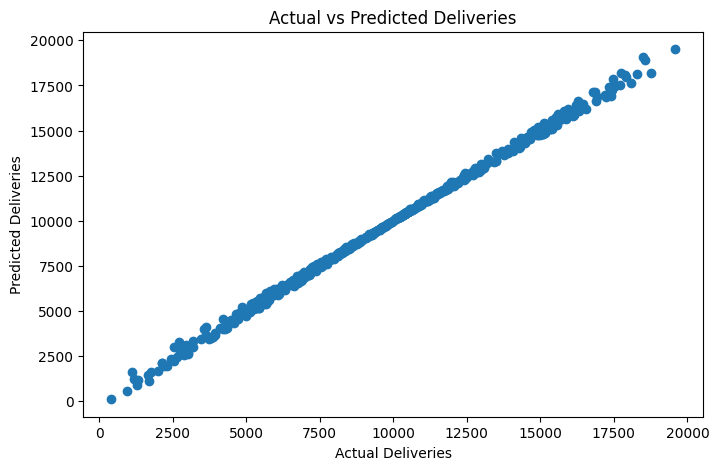

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, ridge_pred)
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted Deliveries")
plt.show()

# Lasso Regression

In [27]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

In [28]:
print("MAE:",
      mean_absolute_error(y_test, lasso_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, lasso_pred)))

print("R2 Score:",
      r2_score(y_test, lasso_pred))

MAE: 108.69479356186812
RMSE: 153.17057901380667
R2 Score: 0.9984260852826138


# CROSS VALIDATION

In [29]:
scores = cross_val_score(
    Ridge(alpha=1.0),
    scaler.fit_transform(X),
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores")
print(scores)

print("Average Score")
print(scores.mean())

Cross Validation Scores
[0.99852088 0.99851237 0.9982327  0.99825527 0.99856033]
Average Score
0.9984163095045719


# HYPERPARAMETER TUNING

In [30]:
parameters = {
    'alpha':[0.01,0.1,1,10,100]
}

In [31]:
grid = GridSearchCV(
    Ridge(),
    parameters,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.01, 0.1, 1, 10, 100]}, scoring='r2')

In [32]:
print("Best Parameters")
print(grid.best_params_)

print("Best Score")
print(grid.best_score_)

Best Parameters
{'alpha': 0.1}
Best Score
0.998409767339821


# TIME SERIES FORECASTING

## Aggregate Yearly Deliveries

In [33]:
yearly_data = df.groupby(
    'Year'
)['Estimated_Deliveries'].sum()

yearly_data

Year
2015    2375267
2016    2434081
2017    2350517
2018    2423104
2019    2404230
2020    2280336
2021    2335116
2022    2434220
2023    2382375
2024    2406899
2025    2368462
Name: Estimated_Deliveries, dtype: int64

## Train ARIMA Model

In [34]:
yearly_data = df.groupby('Year')['Estimated_Deliveries'].sum()

yearly_data.index = pd.to_datetime(yearly_data.index.astype(str))

yearly_data

Year
2015-01-01    2375267
2016-01-01    2434081
2017-01-01    2350517
2018-01-01    2423104
2019-01-01    2404230
2020-01-01    2280336
2021-01-01    2335116
2022-01-01    2434220
2023-01-01    2382375
2024-01-01    2406899
2025-01-01    2368462
Name: Estimated_Deliveries, dtype: int64

In [35]:
model = ARIMA(yearly_data, order=(1,1,1))
result = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


## Forecast Future Deliveries

In [36]:
forecast = result.forecast(steps=3)
print("Forecasted Deliveries")
print(forecast)

Forecasted Deliveries
2026-01-01    2.366761e+06
2027-01-01    2.367844e+06
2028-01-01    2.367155e+06
Freq: YS-JAN, Name: predicted_mean, dtype: float64


# Forecast Visualization

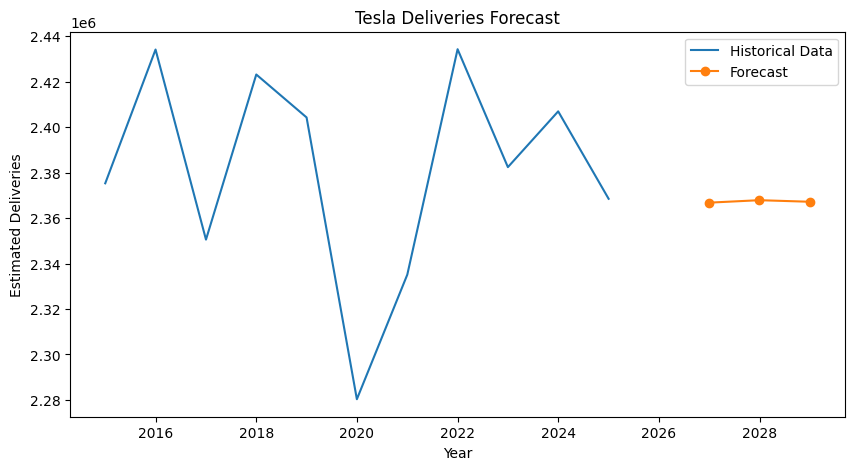

In [37]:
plt.figure(figsize=(10,5))

# Historical Data
plt.plot(
    yearly_data.index,
    yearly_data.values,
    label='Historical Data'
)

# Forecast Data
forecast_index = pd.date_range(
    start=yearly_data.index[-1],
    periods=4,
    freq='Y'
)[1:]

plt.plot(
    forecast_index,
    forecast,
    marker='o',
    label='Forecast'
)

plt.legend()
plt.title("Tesla Deliveries Forecast")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")

plt.show()

# Conclusion

- Loaded and analyzed Tesla sales and pricing data.
- Performed data preprocessing and data quality checks.
- Conducted exploratory data analysis to understand trends and relationships.
- Created new engineered features such as Delivery Efficiency and Price Per Range.
- Applied Ridge and Lasso Regression models for delivery prediction.
- Evaluated model performance using MAE, RMSE and R² Score.
- Performed Cross Validation to ensure model robustness.
- Tuned model hyperparameters using GridSearchCV.
- Forecasted future Tesla deliveries using ARIMA Time Series Forecasting.
- Successfully built an end-to-end Machine Learning Pipeline on sales/price data.